# 02 — EDA Tabular

Este notebook realiza el análisis exploratorio de los tres ficheros de metadatos del dataset Meetup Tennessee:
- **`meta_members`** — atributos de los miembros (ubicación geográfica)
- **`meta_groups`** — atributos de los grupos (categoría, tamaño, organizador)
- **`meta_events`** — eventos por grupo (actividad temporal)

El objetivo es identificar patrones, distribuciones y candidatos a anomalía que orienten tanto el feature engineering como la interpretación de los resultados del GAE.

In [1]:
import os
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
from matplotlib.patches import FancyArrowPatch

from src.utils.visualization import (
    apply_theme, polish, save_figure,
    PALETTE, CAT_COLORS, CMAP_SEQ, CMAP_HEAT, FS, FONT,
)

apply_theme()

## 1. Carga de datos

Cargamos los tres ficheros de metadatos desde `data/processed/` — los mismos CSVs limpios generados en el notebook de preprocesamiento.

In [2]:
# ── Carga ──────────────────────────────────────────────────────────────────

DATA_PATH = '../data/processed/'

meta_members = pd.read_csv(os.path.join(DATA_PATH, 'meta-members.csv'))
meta_groups = pd.read_csv(os.path.join(DATA_PATH, 'meta-groups.csv'))
meta_events = pd.read_csv(os.path.join(DATA_PATH, 'meta-events.csv'))

dfs = {
    "meta_events":  meta_events,
    "meta_groups":  meta_groups,
    "meta_members": meta_members,
}

## 2. Inspección inicial

Revisamos dimensiones, columnas, tipos de datos y calidad de cada DataFrame para orientar el análisis posterior.

In [3]:
# ── Inspección básica ──────────────────────────────────────────────────────
for name, df in dfs.items():
    print(f"{'='*50}")
    print(f"📄 {name}")
    print(f"  Shape      : {df.shape}")
    print(f"  Columnas   : {df.columns.tolist()}")
    print(f"  Tipos      :\n{df.dtypes.to_string()}")
    print(f"\n  Primeras filas:")
    display(df.head(3))

# ── Nulos y duplicados ─────────────────────────────────────────────────────
for name, df in dfs.items():
    print(f"\n📄 {name}")
    nulls = df.isnull().sum()
    nulls_pct = (nulls / len(df) * 100).round(2)
    null_df = pd.DataFrame({"nulos": nulls, "% nulos": nulls_pct})
    print(null_df[null_df["nulos"] > 0] if null_df["nulos"].sum() > 0 else "  ✅ Sin nulos")
    dups = df.duplicated().sum()
    print(f"  Duplicados : {dups}")

📄 meta_events
  Shape      : (19307, 4)
  Columnas   : ['event_id', 'group_id', 'name', 'time']
  Tipos      :
event_id      str
group_id    int64
name          str
time          str

  Primeras filas:


,event_id,group_id,name,time
0,243930425,26140018,2017 Nashville Walk to End Alzheimers - Octob...,2017-10-14 12:00:00
1,244208851,25604533,Steak Dinner on the Patio,2017-10-15 00:15:00
2,pxlktnywnbfb,25973656,Schedule Meetup,2017-10-03 23:30:00


📄 meta_groups
  Shape      : (602, 7)
  Columnas   : ['group_id', 'group_name', 'num_members', 'category_id', 'category_name', 'organizer_id', 'group_urlname']
  Tipos      :
group_id         int64
group_name         str
num_members      int64
category_id      int64
category_name      str
organizer_id     int64
group_urlname      str

  Primeras filas:


,group_id,group_name,num_members,category_id,category_name,organizer_id,group_urlname
0,339011,Nashville Hiking Meetup,15838,23,Outdoors & Adventure,4353803,nashville-hiking
1,19728145,Stepping Out Social Dance Meetup,1778,5,Dancing,118484462,steppingoutsocialdance
2,6335372,Nashville soccer,2869,32,Sports & Recreation,108448302,Nashville-soccer


📄 meta_members
  Shape      : (24591, 6)
  Columnas   : ['member_id', 'name', 'city', 'state', 'lat', 'lon']
  Tipos      :
member_id      int64
name             str
city             str
state            str
lat          float64
lon          float64

  Primeras filas:


,member_id,name,city,state,lat,lon
0,2069,Wesley Duffee-Braun,Brentwood,TN,36.00,-86.79
1,8386,Tim,Nashville,TN,36.07,-86.78
2,9205,Brenda,Brentwood,TN,36.00,-86.79



📄 meta_events
  ✅ Sin nulos
  Duplicados : 0

📄 meta_groups
  ✅ Sin nulos
  Duplicados : 0

📄 meta_members
       nulos  % nulos
state     94     0.38
  Duplicados : 0


---

## 3. EDA — meta_members

### 3.1 Estadísticas básicas

El dataset contiene **24.591 miembros únicos** distribuidos en **893 ciudades distintas** y registrados en **64 "estados"** diferentes, aunque como veremos, no todos son estados válidos de EE.UU.

📊 Estadísticas descriptivas - meta_members


,member_id,name,city,state,lat,lon
count,2.459100e+04,24591,24591,24497,24591.000000,24591.000000
unique,NaN,20850,893,64,NaN,NaN
top,NaN,Jennifer,Nashville,TN,NaN,NaN
freq,NaN,43,14779,22560,NaN,NaN
mean,1.585104e+08,NaN,NaN,NaN,36.163729,-86.450103
std,7.776245e+07,NaN,NaN,NaN,2.306560,10.199460
min,2.069000e+03,NaN,NaN,NaN,-41.280000,-158.030000
25%,1.029967e+08,NaN,NaN,NaN,36.060000,-86.810000
50%,1.950036e+08,NaN,NaN,NaN,36.160000,-86.780000
75%,2.165563e+08,NaN,NaN,NaN,36.170000,-86.720000



👥 Total de miembros: 24591

🗺️ Estados únicos: 64
state
TN    22560
KY      213
IL      194
CA      180
GA      162
NY      137
FL      109
AL      100
TX       91
NC       72
Name: count, dtype: int64

🏙️ Ciudades únicas: 893
city
Nashville         14779
Franklin           1515
Brentwood           850
Murfreesboro        769
Hendersonville      447
Antioch             407
Clarksville         389
Hermitage           382
Mount Juliet        372
Smyrna              284
Spring Hill         260
Madison             183
Goodlettsville      157
Chicago             150
La Vergne           143
Lebanon             134
Gallatin            129
Old Hickory          98
Columbia             93
Nolensville          92
Name: count, dtype: int64
[viz] saved -> C:\Personal\MCD\TFM\results\figures\02_members_top_states_cities.png


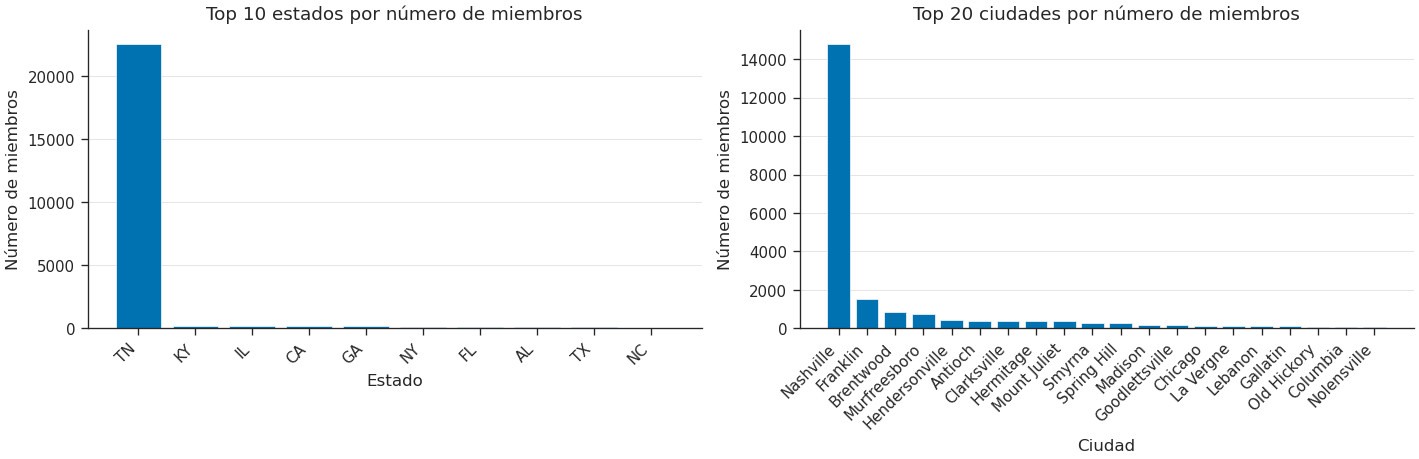


⚠️ Miembros sin 'city'  : 0
⚠️ Miembros sin 'state' : 94

📍 Miembros en Tennessee : 22560 (91.7%)
📍 Miembros fuera de TN  : 2031 (8.3%)


In [4]:
# ── meta_members ───────────────────────────────────────────────────────────
print("📊 Estadísticas descriptivas - meta_members")
display(meta_members.describe(include="all"))

print(f"\n👥 Total de miembros: {meta_members['member_id'].nunique()}")

# Miembros por estado
state_counts = meta_members["state"].value_counts()
print(f"\n🗺️ Estados únicos: {meta_members['state'].nunique()}")
print(state_counts.head(10))

# Miembros por ciudad (top 20)
city_counts = meta_members["city"].value_counts()
print(f"\n🏙️ Ciudades únicas: {meta_members['city'].nunique()}")
print(city_counts.head(20))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=FS["r1c2"])

axes[0].bar(state_counts.head(10).index, state_counts.head(10).values,
            color=PALETTE["M"])
axes[0].set_title("Top 10 estados por número de miembros")
axes[0].set_xlabel("Estado")
axes[0].set_ylabel("Número de miembros")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")
polish(axes[0])

axes[1].bar(city_counts.head(20).index, city_counts.head(20).values,
            color=PALETTE["M"])
axes[1].set_title("Top 20 ciudades por número de miembros")
axes[1].set_xlabel("Ciudad")
axes[1].set_ylabel("Número de miembros")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
polish(axes[1])

plt.tight_layout()
save_figure(fig, "02_members_top_states_cities.png")
plt.show()

# Miembros sin ciudad/estado informado
print(f"\n⚠️ Miembros sin 'city'  : {meta_members['city'].isna().sum()}")
print(f"⚠️ Miembros sin 'state' : {meta_members['state'].isna().sum()}")

# Miembros fuera de Tennessee (anomalía geográfica potencial)
tn_members = meta_members[meta_members["state"] == "TN"]
out_members = meta_members[meta_members["state"] != "TN"]
print(f"\n📍 Miembros en Tennessee : {len(tn_members)} ({len(tn_members)/len(meta_members)*100:.1f}%)")
print(f"📍 Miembros fuera de TN  : {len(out_members)} ({len(out_members)/len(meta_members)*100:.1f}%)")

[viz] saved -> C:\Personal\MCD\TFM\results\figures\02_members_top_states_cities_ex_TN.png


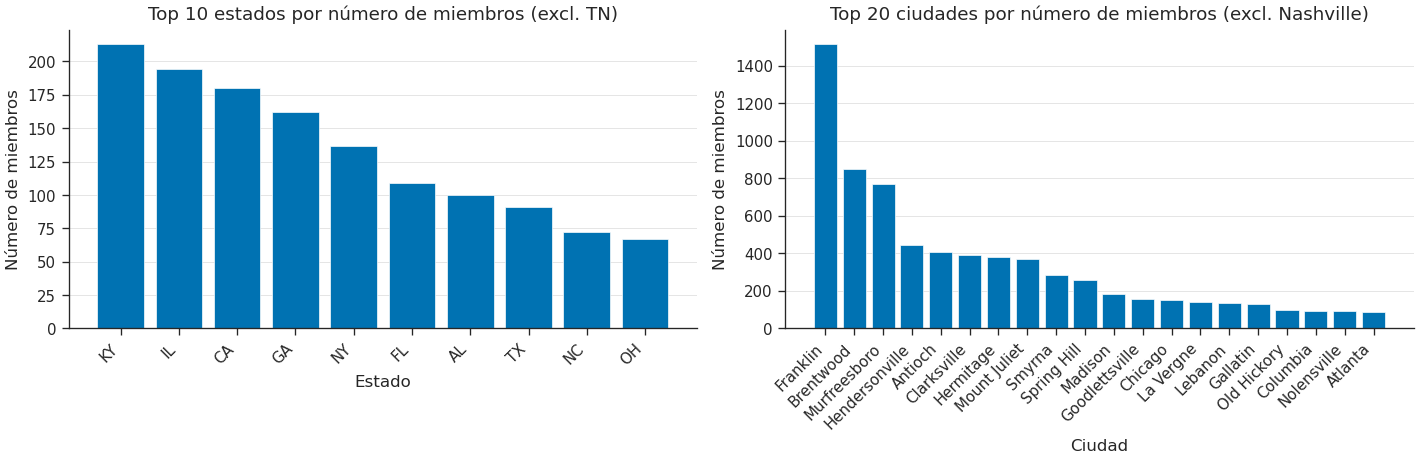

In [5]:
state_counts = meta_members[meta_members["state"] != "TN"]["state"].value_counts()
city_counts = meta_members[meta_members["city"].str.lower() != "nashville"]["city"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=FS["r1c2"])

axes[0].bar(state_counts.head(10).index, state_counts.head(10).values,
            color=PALETTE["M"])
axes[0].set_title("Top 10 estados por número de miembros (excl. TN)")
axes[0].set_xlabel("Estado")
axes[0].set_ylabel("Número de miembros")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")
polish(axes[0])

axes[1].bar(city_counts.head(20).index, city_counts.head(20).values,
            color=PALETTE["M"])
axes[1].set_title("Top 20 ciudades por número de miembros (excl. Nashville)")
axes[1].set_xlabel("Ciudad")
axes[1].set_ylabel("Número de miembros")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
polish(axes[1])

plt.tight_layout()
save_figure(fig, "02_members_top_states_cities_ex_TN.png")
plt.show()

### 3.2 Distribución geográfica

La distribución geográfica es muy concentrada: el **91.7% de los miembros reside en Tennessee**, y dentro de este, **Nashville domina con el 60.1%** del total (14.779 miembros). El resto de ciudades con presencia significativa — Franklin, Brentwood, Murfreesboro, Hendersonville — pertenecen todas al área metropolitana de Nashville, lo cual es coherente con el origen del dataset.

El **8.3% restante** (2.031 miembros) está fuera de Tennessee. Los estados más representados son los vecinos geográficos (Kentucky, Georgia, Alabama), lo que tiene sentido geográficamente. Sin embargo, la presencia de miembros de California, Nueva York o Illinois es más llamativa y podría responder a usuarios que se mudaron o que simplemente se apuntaron a grupos online.

### 3.3 Calidad de datos

Se identificaron tres issues de calidad relevantes.

El primero son los **94 miembros sin valor en `state`**. Un muestreo cualitativo reveló que no se trata de datos corruptos, sino de **miembros internacionales** para los que la plataforma Meetup simplemente no registra estado al no ser un campo aplicable fuera de EE.UU. y Canadá. El mapa mundial confirma esta hipótesis visualmente — todos los puntos morados tienen coordenadas geográficamente coherentes con sus ciudades declaradas.

El segundo son los **20 miembros con códigos de estado inválidos** (valores como "C3", "F8", "17"...). Estos sí representan datos corruptos o mal formateados en la plataforma original, y se guardan como candidatos a anomalías de calidad de datos.

El tercero y más relevante es el de las **coordenadas de centroide**: el **28.9% de los miembros (7.107)** tiene asignadas las coordenadas del centro de su ciudad en lugar de su ubicación real. Esto ocurre cuando el usuario no especifica una dirección concreta y la plataforma resuelve la ubicación a nivel de ciudad. Como consecuencia, las coordenadas no son fiables a nivel individual y cualquier análisis espacial fino debe tratarse con cautela. Esta limitación es visible en el mapa: la alta densidad de puntos superpuestos en la zona de Nashville responde en parte a este fenómeno de centroide, no solo a la concentración real de miembros.

Identificamos primero los miembros con estados no reconocidos como válidos de EE.UU.:

In [6]:
# Estados fuera de los 50 + DC + territorios conocidos
estados_usa = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN",
    "IA","KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV",
    "NH","NJ","NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN",
    "TX","UT","VT","VA","WA","WV","WI","WY","DC","PR","GU","VI","AS","MP"
]

estados_raros = meta_members[~meta_members["state"].isin(estados_usa) & meta_members["state"].notna()]
print(f"⚠️ Miembros con estado no reconocido: {len(estados_raros)}")
print(estados_raros["state"].value_counts())

⚠️ Miembros con estado no reconocido: 37
state
17    8
AB    5
ON    5
QC    4
BC    3
C3    2
F8    2
AA    1
F7    1
CE    1
B7    1
I9    1
RM    1
N7    1
T5    1
Name: count, dtype: int64


In [7]:
# Guardar estos member_ids para referencia futura (candidatos a anomalía de datos)
miembros_estado_raro = estados_raros["member_id"].tolist()
print(f"Member IDs con estado no reconocido guardados: {len(miembros_estado_raro)}")

# Resumen final meta_members
print("\n📋 RESUMEN meta_members")
print(f"  Total miembros        : {len(meta_members)}")
print(f"  Sin estado            : 94")
print(f"  Estado no reconocido  : 37")
print(f"  Canadá                : {estados_raros['state'].isin(['AB','ON','QC','BC']).sum()}")
print(f"  Códigos corruptos     : {(~estados_raros['state'].isin(['AB','ON','QC','BC'])).sum()}")
print(f"  Fuera de TN (válidos) : 2031")
print(f"  En Tennessee          : 22560")

Member IDs con estado no reconocido guardados: 37

📋 RESUMEN meta_members
  Total miembros        : 24591
  Sin estado            : 94
  Estado no reconocido  : 37
  Canadá                : 17
  Códigos corruptos     : 20
  Fuera de TN (válidos) : 2031
  En Tennessee          : 22560


Para confirmar si los nulos en `state` corresponden realmente a miembros internacionales o a datos corruptos, inspeccionamos una muestra de ambos grupos:

In [8]:
# Analizamos las observaciones con y sin nulos en state
print("Muestreo de observaciones con nulos en state:\n", meta_members[meta_members['state'].isna()].sample(5), "\n")

print("Muestreo de observaciones sin nulos en state: \n", meta_members[meta_members['state'].notna()].sample(5))

Muestreo de observaciones con nulos en state:
        member_id               name         city state    lat     lon
8434   162697932      Caroline Jacq    Melbourne   NaN -37.81  144.96
9626   184288149            mohamed         Oslo   NaN  59.91   10.75
9544   184023894    Shailesh Zagade         Pune   NaN  18.53   73.84
15083  204309536  John Ryan Kitchen     Brisbane   NaN -27.46  153.02
4867    66847942      Sierra Rhodes  Montpellier   NaN  43.60    3.88 

Muestreo de observaciones sin nulos en state: 
        member_id              name          city state    lat    lon
8360   161091082             Katie  Mount Juliet    TN  36.22 -86.52
22478  230522918           Jessica       Fairfax    VA  38.83 -77.34
20508  223466391    Peter Balcarce     Nashville    TN  36.17 -86.78
9260   183204710  Cassandra Fuller       Cordova    TN  35.14 -89.76
9346   183460035     Letisha Green       Madison    TN  36.26 -86.71


### 3.4 Visualización geográfica — antes de corrección

El primer mapa muestra todos los miembros coloreados según si tienen `state` informado (rojo) o no (morado). En este punto algunos miembros europeos aparecen en rojo porque tienen códigos de estado inválidos como `17` (Londres), `B7` (Bristol) o `C3` (Cambridge) — no son nulos pero tampoco son estados de EE.UU., por lo que aparecen incorrectamente clasificados como "con estado".

[viz] saved -> C:\Personal\MCD\TFM\results\figures\02_members_map.png


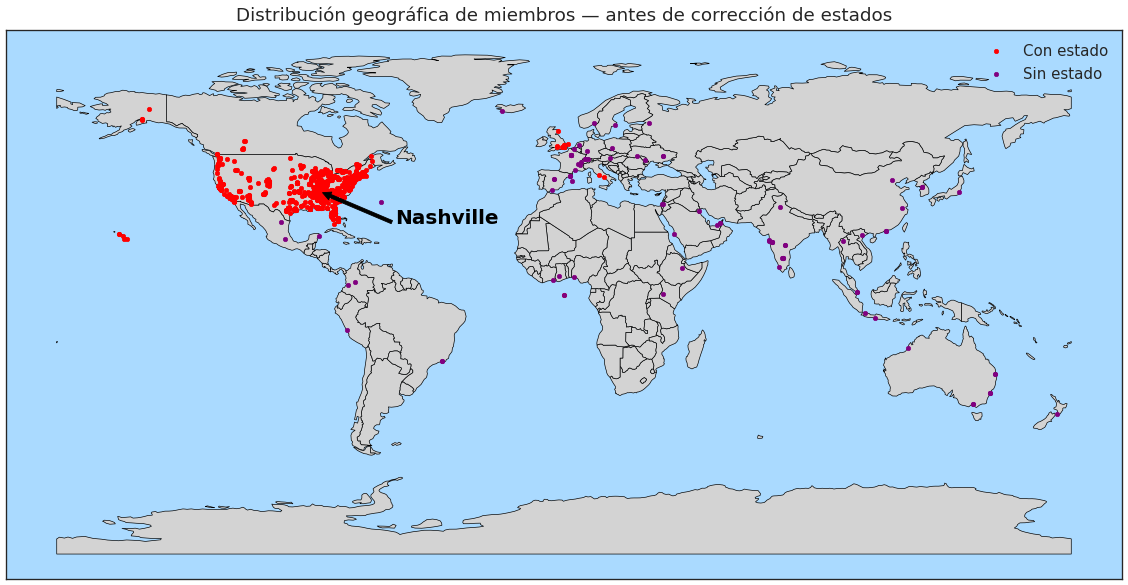

In [9]:
# 1. Cargar el mapa base del mundo
world = gpd.read_file("../map/ne_110m_admin_0_countries.shp")

# Convertir el DataFrame normal a un GeoDataFrame
gdf = gpd.GeoDataFrame(
    meta_members,
    geometry=gpd.points_from_xy(meta_members.lon, meta_members.lat),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor('#aadaff')
world.plot(ax=ax, color='lightgrey', edgecolor='black')

# Miembros con estado informado -> Rojo
gdf[gdf['state'].notna()].plot(ax=ax, color='red', markersize=7, label='Con estado')
# Miembros sin estado -> Morado
gdf[gdf['state'].isna()].plot(ax=ax, color='purple', markersize=7, label='Sin estado')

# Flecha apuntando a Nashville
arrow = FancyArrowPatch(
    (-60, 25), (-86.7816, 36.1627),
    mutation_scale=10, color='black', lw=0.5
)
ax.add_patch(arrow)
ax.text(-60, 25, 'Nashville', fontsize=12, ha='left', color='black', weight='bold')

plt.title('Distribución geográfica de miembros — antes de corrección de estados')
plt.legend()
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
save_figure(fig, "02_members_map.png")
plt.show()

### 3.5 Corrección de coordenadas y estados inválidos

Antes de redibujar el mapa corregido, realizamos tres operaciones de limpieza:

1. **Coordenadas `(0, 0)`**: identificamos si hay miembros con lat/lon a cero — dato claramente inválido. Se corrige manualmente Vijayapura (India), cuyas coordenadas eran `(0, 0)`, y se eliminan las filas restantes con este problema.
2. **Estados inválidos en Europa**: convertimos a `NaN` los estados de miembros cuyas coordenadas los sitúan en Europa (lon > -15) pero tienen un valor no nulo en `state` — son códigos europeos como `17` (Londres) o `B7` (Bristol) que la plataforma asignó incorrectamente.
3. **Estados inválidos en Canadá**: misma corrección para miembros con coordenadas al norte del paralelo 50 fuera de EE.UU.

Inspeccionamos primero los miembros con estado informado pero coordenadas fuera de EE.UU.:

In [10]:
# Miembros con coordenadas (0, 0) o fuera de rango
display(meta_members[(meta_members['lat'] == 0) & (meta_members['lon'] == 0)])
display(meta_members[(meta_members['lat'].isna()) | (meta_members['lon'].isna())])

,member_id,name,city,state,lat,lon
425,4318372,Lena,FPO,AA,0.0,0.0
21189,225822010,Akash Kadabi,Vijayapura,NaN,0.0,0.0


,member_id,name,city,state,lat,lon


In [11]:
meta_members.loc[meta_members['city'] == "Vijayapura", ['lat', 'lon']] = [16.83, 75.72]
meta_members.drop(meta_members[(meta_members['lat'] == 0) & (meta_members['lon'] == 0)].index, inplace=True)

display(meta_members[(meta_members['lat'] == 0) & (meta_members['lon'] == 0)])
display(meta_members[(meta_members['lat'].isna()) | (meta_members['lon'].isna())])

,member_id,name,city,state,lat,lon


,member_id,name,city,state,lat,lon


In [12]:
meta_members[(meta_members['state'].notna()) & (meta_members['lon'] > -15)].sort_values(by='state')

,member_id,name,city,state,lat,lon
756,6721449,Erin,London,17,51.52,-0.10
18047,215214171,MaddyMonteagle,London,17,51.52,-0.10
12958,197481931,Lola,London,17,51.52,-0.10
9723,184651101,Richard,London,17,51.53,-0.10
22200,229405372,Svenja Fischer,London,17,51.52,-0.10
1255,8944058,Michael O'Keefe,London,17,51.52,-0.10
982,7917813,Leia,London,17,51.52,-0.10
3082,15291741,Elle Vee,London,17,51.51,-0.13
10711,188656957,Felicity,Bristol,B7,51.46,-2.60
2603,13327664,Agnieszka Skwark,Cambridge,C3,52.21,0.09


In [13]:
meta_members.loc[(meta_members['state'].notna()) & (meta_members['lon'] > -15), 'state'] = np.nan

In [14]:
meta_members.loc[(meta_members['state'].notna()) & (meta_members['lon'] > -130) & (meta_members['lat'] > 50), 'state'] = np.nan

### 3.6 Visualización geográfica — tras corrección

El mapa resultante confirma la hipótesis: los puntos morados (sin estado) ahora incluyen correctamente tanto los miembros internacionales sin estado informado como los que tenían códigos inválidos. La distribución global de estos puntos es coherente con los perfiles identificados en el muestreo cualitativo: Hong Kong, Lima, Málaga, Kumasi y otras ciudades de distintos continentes.

Los puntos rojos — miembros con estado informado — se concentran de forma casi exclusiva en el sureste de EE.UU., con Nashville como epicentro visible, confirmando que su ausencia de estado no es un error sino una limitación del campo para usuarios fuera de EE.UU.

[viz] saved -> C:\Personal\MCD\TFM\results\figures\02_members_map_fixed.png


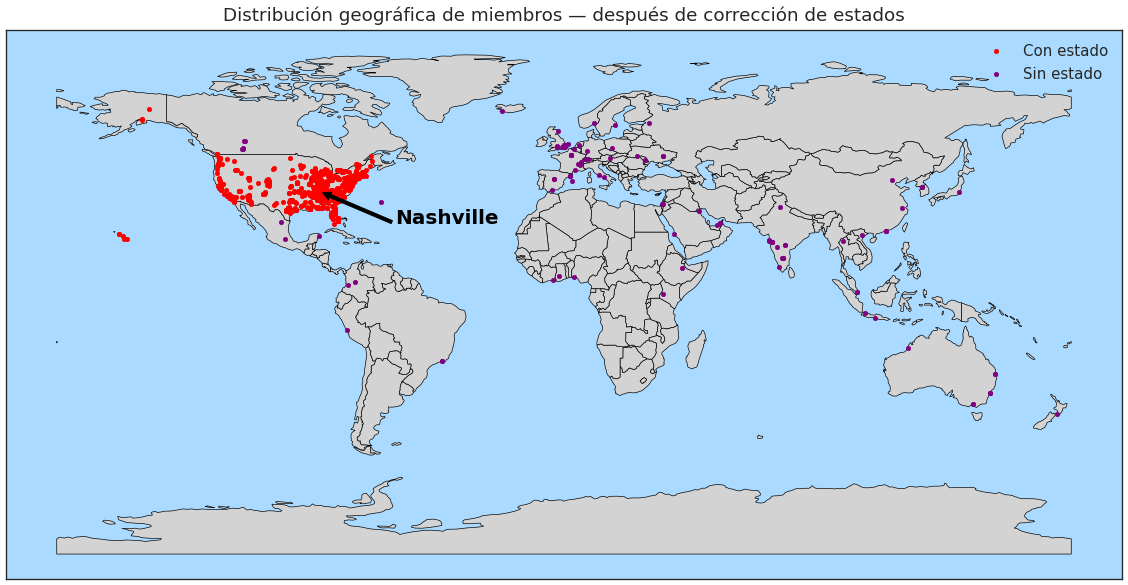

In [17]:
# 1. Cargar el mapa base del mundo
world = gpd.read_file("../map/ne_110m_admin_0_countries.shp")

# 3. Convertir el DataFrame normal a un GeoDataFrame
gdf = gpd.GeoDataFrame(
    meta_members,
    geometry=gpd.points_from_xy(meta_members.lon, meta_members.lat),
    crs="EPSG:4326"
)

# 4. Graficar
fig, ax = plt.subplots(figsize=(12, 6))

ax.set_facecolor('#aadaff')
# Dibujamos el mapa base (color gris claro)
world.plot(ax=ax, color='lightgrey', edgecolor='black')

# --- CAMBIO AQUÍ: Graficamos por separado según el valor de 'state' ---

# Puntos con valores (No nulos) en 'state' -> Rojo
gdf[gdf['state'].notna()].plot(ax=ax, color='red', markersize=7, label='Con estado')

# Puntos con valores faltantes (NaN) en 'state' -> Verde
gdf[gdf['state'].isna()].plot(ax=ax, color='purple', markersize=7, label='Sin estado')

# --- Agregar una flecha que apunte hacia Nashville y el texto ---
lat_nashville = 36.1627
lon_nashville = -86.7816

# Dibujar la flecha (de Europa a Nashville, por ejemplo)
arrow = FancyArrowPatch(
    (-60, 25),  # Coordenada inicial (fuente de la flecha)
    (lon_nashville, lat_nashville),  # Coordenada de destino (Nashville)
    mutation_scale=10, color='black', lw=0.5
)
ax.add_patch(arrow)

# Agregar el texto cerca de Nashville
ax.text(-60, 25, 'Nashville', fontsize=12, ha='left', color='black', weight='bold')

# ---------------------------------------------------------------------

plt.title('Distribución geográfica de miembros — después de corrección de estados')
plt.legend()
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
save_figure(fig, "02_members_map_fixed.png")
plt.show()

### 3.7 Coordenadas de centroide

Al analizar los posibles duplicados por nombre y ciudad, observamos que muchos comparten exactamente las mismas coordenadas. Las coordenadas que se repiten con más frecuencia son siempre las mismas:

- `(36.17, -86.78)` → centro de Nashville
- `(35.92, -86.89)` → centro de Franklin
- `(36.08, -86.72)` → otro punto fijo de Nashville

Esto no indica duplicados reales — son coordenadas del **centroide de la ciudad** que Meetup asigna cuando el usuario no especifica su ubicación exacta.

In [18]:
# Posibles duplicados reales (misma persona, distinto ID)
dupes = meta_members.duplicated(subset=['name', 'city'], keep=False)
print(f"Posibles duplicados por nombre+ciudad: {dupes.sum()}")
meta_members[dupes].sort_values('name').head(20)

Posibles duplicados por nombre+ciudad: 2899


,member_id,name,city,state,lat,lon
11620,192498897,A,Nashville,TN,36.18,-86.74
7087,128415212,A,Nashville,TN,36.16,-86.79
5710,90887122,AJ,Nashville,TN,36.17,-86.78
13694,199375748,AJ,Nashville,TN,36.09,-86.82
7110,128992462,Aaron,Nashville,TN,36.17,-86.78
15605,206233966,Aaron,Nashville,TN,36.08,-86.72
7557,141211622,Aaron Johnson,Nashville,TN,36.16,-86.79
3672,33303272,Aaron Johnson,Nashville,TN,36.18,-86.74
4417,55003212,Abby,Nashville,TN,36.08,-86.72
5498,85061842,Abby,Nashville,TN,36.13,-86.80


In [19]:
# Duplicados más sospechosos: mismo nombre + mismas coordenadas exactas
dupes_strict = meta_members.duplicated(subset=['name', 'lat', 'lon'], keep=False)
print(f"Duplicados por nombre+coordenadas exactas: {dupes_strict.sum()}")
meta_members[dupes_strict].sort_values('name').head(20)

Duplicados por nombre+coordenadas exactas: 1128


,member_id,name,city,state,lat,lon
10369,187214447,Abby,Nashville,TN,36.17,-86.78
16628,209929200,Abby,Nashville,TN,36.17,-86.78
18986,218424925,Abraham,Nashville,TN,36.17,-86.78
16274,208665030,Abraham,Nashville,TN,36.17,-86.78
13014,197633957,Adam,Franklin,TN,35.92,-86.89
9786,184892012,Adam,Franklin,TN,35.92,-86.89
14197,200961984,Adam Amroun,Nashville,TN,36.17,-86.78
19893,221514468,Adam Amroun,Nashville,TN,36.17,-86.78
16396,209078263,Alan,Nashville,TN,36.17,-86.78
2472,12876655,Alan,Nashville,TN,36.08,-86.72


Esto confirma que no son duplicados reales sino el fenómeno de centroide: Meetup asigna la coordenada central de la ciudad cuando el usuario no especifica dirección concreta. Esto tiene implicaciones directas para el feature engineering — las coordenadas `lat` y `lon` no son fiables a nivel individual para el 28.9% de los miembros, aunque siguen siendo geográficamente coherentes a nivel de ciudad.

In [20]:
# Verificar cuántos miembros tienen coordenadas de centroides conocidos
centroides = [
    (36.17, -86.78),  # Nashville centro
    (35.92, -86.89),  # Franklin centro
    (36.08, -86.72),  # Nashville sur
]

centroide_mask = meta_members.apply(
    lambda r: (round(r['lat'], 2), round(r['lon'], 2)) in centroides, axis=1
)
print(f"Miembros con coordenadas de centroide: {centroide_mask.sum()}")
print(f"Porcentaje: {centroide_mask.sum()/len(meta_members)*100:.1f}%")

Miembros con coordenadas de centroide: 7107
Porcentaje: 28.9%


### 3.8 Guardado de meta_members corregido

Guardamos el DataFrame con todas las correcciones aplicadas — estados inválidos convertidos a NaN, coordenadas de Vijayapura corregidas y filas con `(0,0)` eliminadas.

In [21]:
meta_members.to_csv(f"../data/processed/meta-members.csv", index=False)

### 3.9 Relevancia para detección de anomalías

Los miembros internacionales, los de fuera de Tennessee y los que presentan datos de estado corruptos constituyen un primer conjunto de **candidatos a anomalía**, no necesariamente por comportamiento anómalo en el grafo, sino por su naturaleza atípica dentro de una red fundamentalmente local. Será interesante contrastar en fases posteriores si estos perfiles también presentan patrones de conexión inusuales.

---

## 4. EDA — meta_groups

### 4.1 Estadísticas básicas

El dataset contiene **602 grupos únicos** distribuidos en **31 categorías temáticas**, organizados por **522 organizadores distintos**. La ratio de casi un organizador por grupo indica que la mayoría de los grupos tienen un gestor dedicado, aunque como veremos, hay excepciones relevantes.

📊 Estadísticas descriptivas - meta_groups


,group_id,group_name,num_members,category_id,category_name,organizer_id,group_urlname
count,6.020000e+02,602,602.000000,602.000000,602,6.020000e+02,602
unique,NaN,602,NaN,NaN,31,NaN,602
top,NaN,Nashville Hiking Meetup,NaN,NaN,Tech,NaN,nashville-hiking
freq,NaN,1,NaN,NaN,100,NaN,1
mean,1.690675e+07,NaN,551.438538,19.126246,NaN,1.106295e+08,NaN
std,8.149222e+06,NaN,1002.694813,11.870096,NaN,8.745972e+07,NaN
min,4.709400e+04,NaN,2.000000,1.000000,NaN,8.386000e+03,NaN
25%,1.201376e+07,NaN,67.000000,9.000000,NaN,1.255313e+07,NaN
50%,1.946904e+07,NaN,201.500000,21.000000,NaN,1.080864e+08,NaN
75%,2.287458e+07,NaN,600.000000,31.000000,NaN,1.967602e+08,NaN



👥 Total de grupos: 602
📂 Categorías únicas: 31
🧑‍💼 Organizadores únicos: 522

📂 Grupos por categoría:
category_name
Tech                          100
Career & Business              93
Socializing                    48
Outdoors & Adventure           36
Health & Wellbeing             36
New Age & Spirituality         33
Sports & Recreation            26
Games                          20
Community & Environment        20
Music                          19
Religion & Beliefs             18
Food & Drink                   15
Fitness                        14
Education & Learning           13
Language & Ethnic Identity     13
Movements & Politics           12
Book Clubs                     11
Arts & Culture                  9
Support                         9
Parents & Family                7
Pets & Animals                  6
LGBT                            6
Hobbies & Crafts                6
Movies & Film                   6
Dancing                         5
Photography                     5

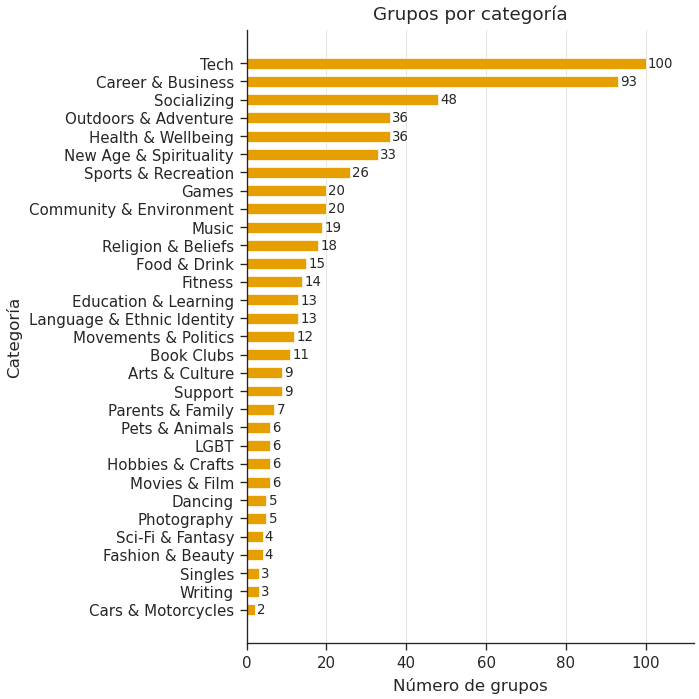

In [22]:
# ── meta_groups ────────────────────────────────────────────────────────────
print("📊 Estadísticas descriptivas - meta_groups")
display(meta_groups.describe(include="all"))

print(f"\n👥 Total de grupos: {meta_groups['group_id'].nunique()}")
print(f"📂 Categorías únicas: {meta_groups['category_id'].nunique()}")
print(f"🧑\u200d💼 Organizadores únicos: {meta_groups['organizer_id'].nunique()}")

# Distribución por categoría
cat_counts = meta_groups['category_name'].value_counts()
print(f"\n📂 Grupos por categoría:\n{cat_counts}")

# Estadísticas de num_members
print(f"\n👥 Estadísticas de num_members:")
print(meta_groups['num_members'].describe())

# Organizadores con más de un grupo
org_counts = meta_groups['organizer_id'].value_counts()
print(f"\n🧑\u200d💼 Organizadores con más de 1 grupo: {(org_counts > 1).sum()}")
print(org_counts[org_counts > 1].head(10))

# Visualización
fig, ax = plt.subplots(figsize=(6, 6))  # más alto para dar espacio entre barras

ax.barh(cat_counts.index, cat_counts.values, color=PALETTE["G"], height=0.6)
ax.invert_yaxis()

for i, (val, cat) in enumerate(zip(cat_counts.values, cat_counts.index)):
    ax.text(val + 0.5, i, str(val), va="center", fontsize=FONT["annotation"])

ax.set_xlim(0, cat_counts.max() * 1.12)  # margen para las etiquetas
ax.set_title("Grupos por categoría")
ax.set_xlabel("Número de grupos")
ax.set_ylabel("Categoría")
polish(ax, grid_axis="x")

plt.tight_layout()
save_figure(fig, "02_groups_category_dist.png")
plt.show()

### 4.2 Distribución de num_members

La distribución de `num_members` presenta una **fuerte asimetría positiva** característica de redes sociales, con una media de 551 miembros muy por encima de la mediana de 201. El rango es extremadamente amplio, desde grupos con apenas 2 miembros hasta el grupo más grande con **15.838 miembros** (Nashville Hiking Meetup).

La comparación entre media y mediana por categoría revela qué categorías están dominadas por uno o pocos grupos gigantes. Outdoors & Adventure presenta la mayor asimetría (media 1.651 vs. mediana 763), consecuencia directa del peso de Nashville Hiking Meetup. Photography muestra un patrón similar (media 971 vs. mediana 318) por la influencia de Nashville Social Crew (4.017 miembros).

[viz] saved -> C:\Personal\MCD\TFM\results\figures\02_groups_members_distribution.png


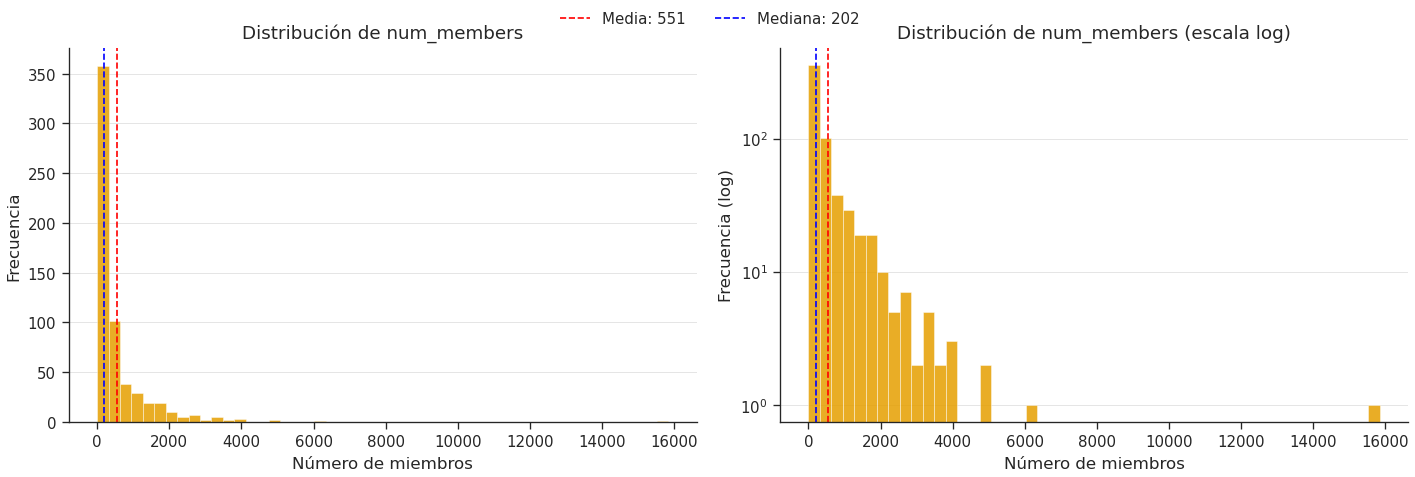

In [23]:
fig, axes = plt.subplots(1, 2, figsize=FS["r1c2"])

mean_val   = meta_groups['num_members'].mean()
median_val = meta_groups['num_members'].median()

for ax in axes:
    ax.hist(meta_groups['num_members'], bins=50, color=PALETTE["G"],
            alpha=0.85, edgecolor="white", linewidth=0.3,
            log=(ax == axes[1]))
    ax.axvline(mean_val,   color="red",  linestyle="--", linewidth=1.0)
    ax.axvline(median_val, color="blue", linestyle="--", linewidth=1.0)

axes[0].set_title("Distribución de num_members")
axes[0].set_xlabel("Número de miembros")
axes[0].set_ylabel("Frecuencia")
polish(axes[0])

axes[1].set_title("Distribución de num_members (escala log)")
axes[1].set_xlabel("Número de miembros")
axes[1].set_ylabel("Frecuencia (log)")
axes[1].yaxis.set_major_locator(plt.LogLocator(base=10, numticks=10))
axes[1].yaxis.set_major_formatter(plt.LogFormatterMathtext(base=10, labelOnlyBase=True))
axes[1].yaxis.set_minor_locator(plt.NullLocator())
polish(axes[1])

# Leyenda única centrada entre los dos subplots
handles = [
    plt.Line2D([0], [0], color="red",  linestyle="--", linewidth=1.0, label=f"Media: {mean_val:.0f}"),
    plt.Line2D([0], [0], color="blue", linestyle="--", linewidth=1.0, label=f"Mediana: {median_val:.0f}"),
]
fig.legend(handles=handles, loc="upper center", ncol=2,
           frameon=False, fontsize=FONT["legend"],
           bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
save_figure(fig, "02_groups_members_distribution.png")
plt.show()

### 4.3 Grupos extremos

Aplicando el criterio IQR (umbral superior: 1.400 miembros), se identifican **68 grupos outlier** (11.3% del total), entre los que destacan Nashville Hiking Meetup (15.838), Paddle Adventures Unlimited (6.331) y Eat Love Nash (5.008). En el extremo opuesto, **13 grupos tienen menos de 10 miembros**, correspondiendo en su mayoría a grupos de Support, Career & Business y categorías muy específicas, que probablemente sean grupos recién creados o abandonados.

Grupos con menos de 10 miembros:
                                            group_name  \
547                 Nashville Business Strategy Meetup   
364  Fight against Alzheimer’s Disease/Walk'n to En...   
450              Chihuahua's Nashville - Tiny & Mighty   
439                           Nashville Women & Beauty   
548           Bellevue Business Buzz Networking  Group   
427  Nashville Digital Currency Ecommerce Opportuni...   
513  Trichotillomania and Skin-Picking Disorder Sup...   
365  Nashville OCD Support Group for Friends & Fami...   
340             Franklin Essentially doTERRA Workshops   
400  witchcraft united - leading, teaching, learnin...   
522  For Women Only - How to Not Run Out of Cash in...   
554                     Sumner County Moms in Business   
576  Franklin/Nashville Parental Alienation Support...   

               category_name  num_members  
547        Career & Business            2  
364  Community & Environment            3  
450           Pets & A

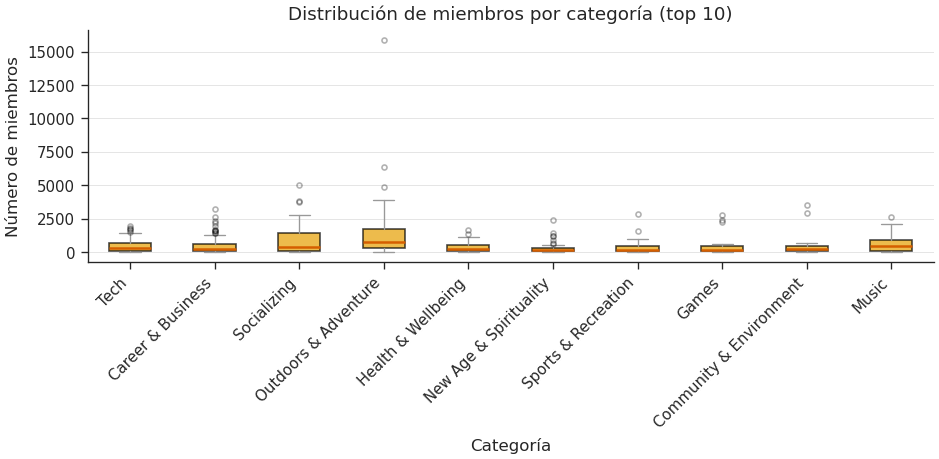

In [24]:
# Grupos muy pequeños (posibles grupos inactivos o abandonados)
print("Grupos con menos de 10 miembros:")
print(meta_groups[meta_groups['num_members'] < 10][
    ['group_name', 'category_name', 'num_members']
].sort_values('num_members'))

# Distribución por categoría weighted por num_members
cat_members = meta_groups.groupby('category_name')['num_members'].sum().sort_values(ascending=False)
print("\nMiembros totales por categoría:")
print(cat_members)

# Boxplot por categoría (top 10)
top_cats = meta_groups['category_name'].value_counts().head(10).index
data_by_cat = [
    meta_groups[meta_groups['category_name'] == c]['num_members'].values
    for c in top_cats
]

fig, ax = plt.subplots(figsize=FS["wide"])
bp = ax.boxplot(
    data_by_cat,
    patch_artist=True,
    medianprops=dict(color=PALETTE["anomaly"], linewidth=1.5),
    boxprops=dict(facecolor=PALETTE["G"], alpha=0.7),
    whiskerprops=dict(color=PALETTE["neutral"], linewidth=0.8),
    capprops=dict(color=PALETTE["neutral"], linewidth=0.8),
    flierprops=dict(marker="o", color=PALETTE["neutral"], alpha=0.3, markersize=3),
)
ax.set_xticks(range(1, len(top_cats) + 1))
ax.set_xticklabels(top_cats, rotation=45, ha="right")
ax.set_title("Distribución de miembros por categoría (top 10)")
ax.set_xlabel("Categoría")
ax.set_ylabel("Número de miembros")
polish(ax)
plt.tight_layout()
save_figure(fig, "02_groups_members_by_category_boxplot.png")
plt.show()

### 4.4 Distribución por categoría

La distribución de grupos por categoría está claramente sesgada hacia dos temáticas dominantes: **Tech** (100 grupos, 16.6%) y **Career & Business** (93 grupos, 15.5%), que juntas concentran casi un tercio del total. En el extremo opuesto, categorías como Cars & Motorcycles (2 grupos), Singles (3) o Writing (3) tienen una presencia testimonial.

Sin embargo, el número de grupos por categoría no refleja fielmente su peso real en la red. Al analizar el **total de miembros acumulados por categoría**, emerge un patrón distinto: **Outdoors & Adventure lidera con 59.445 miembros totales** a pesar de tener solo 36 grupos, superando a Tech (46.227) y Career & Business (44.302). Esto revela que sus grupos son de media mucho más grandes — 1.651 miembros por grupo frente a los 462 de Tech.

El análisis por categoría permite identificar cuatro perfiles claramente diferenciados. En el cuadrante de pocos grupos y media alta destacan Outdoors & Adventure, Singles, Writing y Dancing — categorías de nicho popular con grupos muy concurridos. En el cuadrante de pocos grupos y media baja se sitúan Support, Hobbies & Crafts y Parents & Family, con comunidades pequeñas y homogéneas. Tech y Career & Business ocupan el cuadrante de muchos grupos y media moderada, acumulando volumen total gracias a su cantidad. Socializing ocupa una posición central equilibrada con un volumen total considerable.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
c:\Personal\MCD\TFM\notebooks\..\src\utils\visualization.py:128: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis=grid_axis, color="#E5E5E5", linewidth=0.6, zorder=0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\02_groups_category_scatter.png


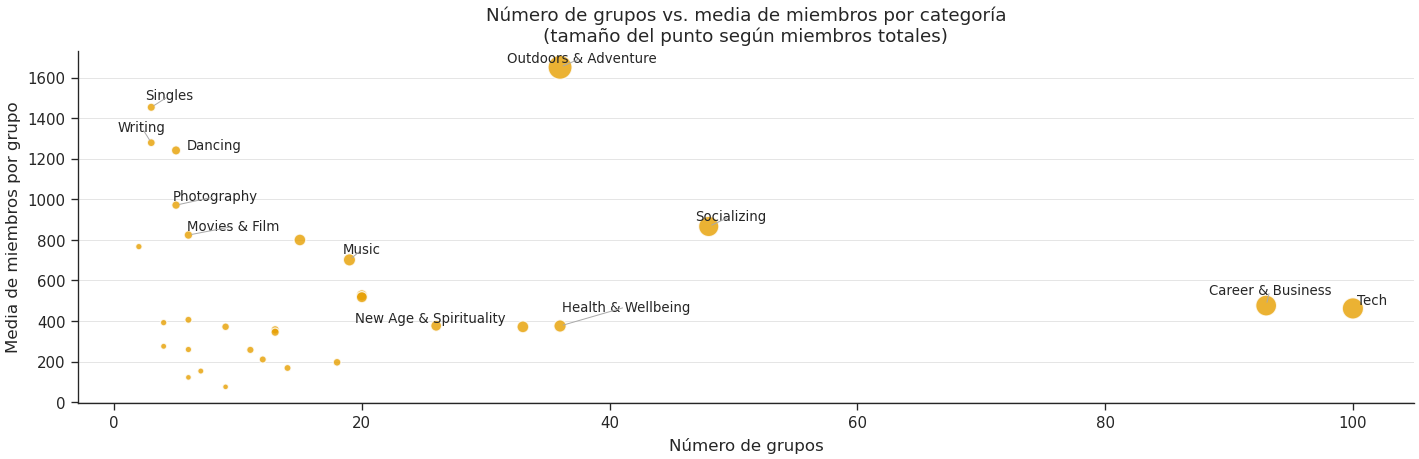

In [25]:
from adjustText import adjust_text

cat_summary = meta_groups.groupby('category_name').agg(
    num_groups=('group_id', 'count'),
    total_members=('num_members', 'sum'),
    avg_members=('num_members', 'mean'),
    median_members=('num_members', 'median')
).sort_values('total_members', ascending=False)

fig, ax = plt.subplots(figsize=FS["r1c2"])

scatter = ax.scatter(
    cat_summary['num_groups'], cat_summary['avg_members'],
    s=cat_summary['total_members'] / 300 + 10,  # +40 para un mínimo visible
    color=PALETTE["G"], alpha=0.80,
    edgecolors="white", linewidths=0.8,
    zorder=3
)

# Solo etiquetamos los más destacados
notable = cat_summary[
    (cat_summary['num_groups'] >= 30) |
    (cat_summary['avg_members'] >= 800) |
    (cat_summary['total_members'] >= cat_summary['total_members'].quantile(0.80))
]

texts = []
for cat, row in notable.iterrows():
    texts.append(ax.text(
        row['num_groups'], row['avg_members'], cat,
        fontsize=FONT["annotation"], ha='center', va='bottom'
    ))

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.6),
    expand_points=(1.5, 1.5),
    expand_text=(1.3, 1.3),
)

ax.set_title("Número de grupos vs. media de miembros por categoría\n"
             "(tamaño del punto según miembros totales)")
ax.set_xlabel("Número de grupos")
ax.set_ylabel("Media de miembros por grupo")
polish(ax, grid=False)
plt.tight_layout()
save_figure(fig, "02_groups_category_scatter.png")
plt.show()

### 4.5 Análisis de organizadores

De los 522 organizadores únicos, **457 (87.5%) gestionan un único grupo**, 51 gestionan dos y solo 14 organizan tres o más. El organizador más activo es **Micah Redding** con 4 grupos en 3 categorías distintas (Religion & Beliefs y Tech), seguido de trece organizadores con 3 grupos cada uno.

Atendiendo al volumen de miembros acumulados, destacan **Michael Gabelman** (5.334 miembros, Outdoors & Adventure y Socializing) y **Charles** (4.962 miembros, Music, Socializing y Career & Business) como los organizadores de mayor alcance. Ambos gestionan grupos en categorías temáticamente diversas, lo que anticipa un rol de nodo puente entre comunidades en el grafo.

Merece mención especial el perfil de **Jubilee Church**, una organización religiosa que organiza grupos de Language & Ethnic Identity, Food & Drink y Music, utilizando Meetup presumiblemente como herramienta de dinamización comunitaria. Igualmente llamativo es el caso del organizador `221183678` (sin perfil de miembro registrado), responsable de tres grupos **#Resist** distribuidos geográficamente por Brentwood, Antioch y Franklin — un patrón de activismo político coordinado que resulta estructuralmente relevante para la detección de anomalías.

In [26]:
# Organizadores con múltiples grupos
org_group = meta_groups.groupby('organizer_id').agg(
    num_groups=('group_id', 'count'),
    categories=('category_name', lambda x: list(x)),
    total_members=('num_members', 'sum')
).sort_values('num_groups', ascending=False)

print("Top organizadores por nº de grupos:")
print(org_group.head(10))

# Organizadores que gestionan grupos de distintas categorías
org_group['num_categories'] = org_group['categories'].apply(lambda x: len(set(x)))
multi_cat = org_group[org_group['num_categories'] > 1]
print(f"\nOrganizadores con grupos en más de 1 categoría: {len(multi_cat)}")
print(multi_cat.sort_values('num_groups', ascending=False).head(10))

Top organizadores por nº de grupos:
              num_groups                                         categories  \
organizer_id                                                                  
2256087                4  [Religion & Beliefs, Tech, Religion & Beliefs,...   
59643462               3  [Education & Learning, Outdoors & Adventure, S...   
34583172               3  [Career & Business, New Age & Spirituality, He...   
208888939              3                        [Support, Support, Support]   
221183678              3  [Movements & Politics, Movements & Politics, M...   
198986314              3       [Career & Business, Career & Business, Tech]   
5129031                3            [Music, Socializing, Career & Business]   
34842792               3                                 [Tech, Tech, Tech]   
201134776              3  [Language & Ethnic Identity, Food & Drink, Music]   
10119159               3       [Career & Business, Tech, Career & Business]   

              t

c:\Personal\MCD\TFM\notebooks\..\src\utils\visualization.py:128: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis=grid_axis, color="#E5E5E5", linewidth=0.6, zorder=0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\02_organizers_groups_members_scatter.png


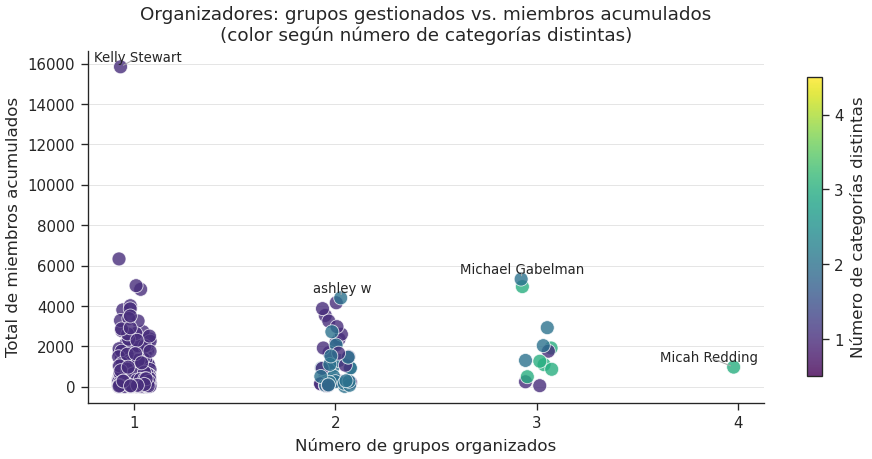

In [27]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=FS["wide"])

np.random.seed(42)
jitter = np.random.uniform(-0.08, 0.08, size=len(org_group))

n_cats = org_group["num_categories"].astype(int)
scatter = ax.scatter(
    org_group["num_groups"] + jitter,
    org_group["total_members"],
    c=n_cats,
    cmap=CMAP_SEQ,
    vmin=0.5, vmax=4.5,
    alpha=0.80,
    s=70,
    edgecolors="white",
    linewidths=0.5,
    zorder=3
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.85)
cbar.set_ticks([1, 2, 3, 4])
cbar.set_label("Número de categorías distintas", fontsize=FONT["axis_label"])

id_to_name = meta_members.set_index("member_id")["name"].to_dict()

# Top 1 por total_members dentro de cada valor de num_groups
texts = []
for n_groups, group_df in org_group.groupby("num_groups"):
    top_row = group_df.nlargest(1, "total_members").iloc[0]
    org_id = group_df.nlargest(1, "total_members").index[0]
    label = id_to_name.get(int(org_id), str(int(org_id)))
    jitter_val = jitter[org_group.index.get_loc(org_id)]
    texts.append(ax.text(
        top_row["num_groups"] + jitter_val,
        top_row["total_members"],
        label,
        fontsize=FONT["annotation"], ha="center", va="bottom"
    ))

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.6),
    expand_points=(1.8, 1.8),
)

ax.set_xticks([1, 2, 3, 4])
ax.set_xlabel("Número de grupos organizados")
ax.set_ylabel("Total de miembros acumulados")
ax.set_title("Organizadores: grupos gestionados vs. miembros acumulados\n"
             "(color según número de categorías distintas)")
polish(ax, grid=False)
plt.tight_layout()
save_figure(fig, "02_organizers_groups_members_scatter.png")
plt.show()

In [28]:
# Verificar si organizer_id está en meta_members
top_organizers = org_group[org_group['num_groups'] >= 3].index.tolist()

matches = meta_members[meta_members['member_id'].isin(top_organizers)]
print(f"Organizadores con 3+ grupos encontrados en meta_members: {len(matches)}")
print(matches[['member_id', 'name', 'city', 'state']])

Organizadores con 3+ grupos encontrados en meta_members: 12
       member_id               name       city state
123      1720391            Kathryn  Nashville    TN
179      2256087      Micah Redding  Nashville    TN
532      5129031            Charles  Nashville    TN
768      6780662  Becki Baumgartner  Nashville    TN
1647    10119159         Ross Jones  Hermitage    TN
3717    34240622   Michael Gabelman  Nashville    TN
3728    34583172       Robin Barnes   Franklin    TN
3741    34842792         Anna Hamil  Nashville    TN
4600    59643462    Diane Giambalvo  Brentwood    TN
10428  187452711     Christine Palm   Franklin    TN
14236  201134776     Jubilee Church  Nashville    TN
16337  208888939               Leah  Nashville    TN


In [29]:
# Enriquecer org_group con datos de meta_members
org_enriched = org_group[org_group['num_groups'] >= 3].merge(
    meta_members[['member_id', 'name', 'city', 'state']],
    left_index=True,
    right_on='member_id',
    how='left'
).set_index('member_id')

print(org_enriched[['name', 'city', 'state', 'num_groups', 'num_categories', 'total_members', 'categories']])

                        name       city state  num_groups  num_categories  \
member_id                                                                   
2256087        Micah Redding  Nashville    TN           4               3   
59643462     Diane Giambalvo  Brentwood    TN           3               3   
34583172        Robin Barnes   Franklin    TN           3               3   
208888939               Leah  Nashville    TN           3               1   
221183678                NaN        NaN   NaN           3               1   
198986314                NaN        NaN   NaN           3               2   
5129031              Charles  Nashville    TN           3               3   
34842792          Anna Hamil  Nashville    TN           3               1   
201134776     Jubilee Church  Nashville    TN           3               3   
10119159          Ross Jones  Hermitage    TN           3               2   
34240622    Michael Gabelman  Nashville    TN           3               2   

In [30]:
# ── Análisis de organizadores ──────────────────────────────────────────────

# 1. Resumen por organizador
org_group = meta_groups.groupby('organizer_id').agg(
    num_groups=('group_id', 'count'),
    categories=('category_name', lambda x: list(x)),
    total_members=('num_members', 'sum')
).sort_values('num_groups', ascending=False)

org_group['num_categories'] = org_group['categories'].apply(lambda x: len(set(x)))

# 2. Enriquecer con meta_members — NaN → "Sin información"
org_enriched = org_group.merge(
    meta_members[['member_id', 'name', 'city', 'state']],
    left_index=True,
    right_on='member_id',
    how='left'
).set_index('member_id')

org_enriched['name']  = org_enriched['name'].fillna('Sin información')
org_enriched['city']  = org_enriched['city'].fillna('Sin información')
org_enriched['state'] = org_enriched['state'].fillna('Sin información')

# 3. Estadísticas generales
print("📊 Estadísticas generales de organizadores")
print(f"  Total organizadores únicos         : {len(org_enriched)}")
print(f"  Organizadores con 1 grupo          : {(org_enriched['num_groups'] == 1).sum()}")
print(f"  Organizadores con 2 grupos         : {(org_enriched['num_groups'] == 2).sum()}")
print(f"  Organizadores con 3+ grupos        : {(org_enriched['num_groups'] >= 3).sum()}")
print(f"  Organizadores no en meta_members   : {(org_enriched['name'] == 'Sin información').sum()}")
print(f"  Organizadores multi-categoría      : {(org_enriched['num_categories'] > 1).sum()}")

# 4. Top organizadores por nº de grupos
print("\n👤 Top organizadores por nº de grupos:")
cols = ['name', 'city', 'state', 'num_groups', 'num_categories', 'total_members']
print(org_enriched[org_enriched['num_groups'] >= 3][cols].to_string())

# 5. Distribución de nº de grupos por organizador
print("\n📊 Distribución de nº de grupos por organizador:")
print(org_enriched['num_groups'].value_counts().sort_index())

📊 Estadísticas generales de organizadores
  Total organizadores únicos         : 522
  Organizadores con 1 grupo          : 457
  Organizadores con 2 grupos         : 51
  Organizadores con 3+ grupos        : 14
  Organizadores no en meta_members   : 29
  Organizadores multi-categoría      : 39

👤 Top organizadores por nº de grupos:
                        name             city            state  num_groups  num_categories  total_members
member_id                                                                                                
2256087        Micah Redding        Nashville               TN           4               3            979
59643462     Diane Giambalvo        Brentwood               TN           3               3           1924
34583172        Robin Barnes         Franklin               TN           3               3           1100
208888939               Leah        Nashville               TN           3               1             60
221183678    Sin información 

[viz] saved -> C:\Personal\MCD\TFM\results\figures\02_organizers_groups_distribution.png


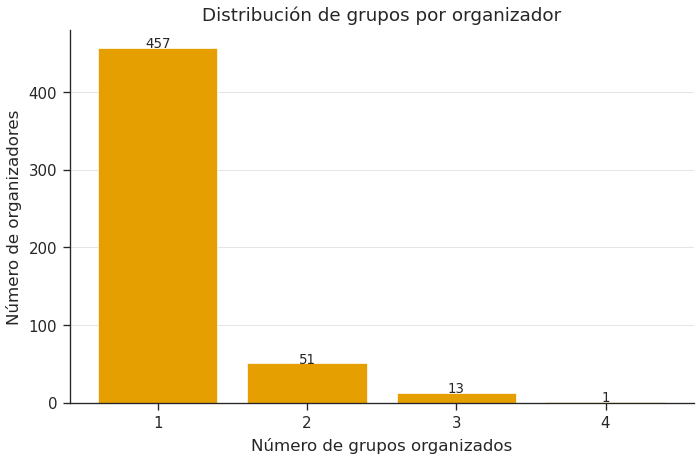

In [31]:
# ── Visualización ──────────────────────────────────────────────────────────

# Distribución de nº de grupos por organizador
fig, ax = plt.subplots(figsize=FS["single"])

org_dist = org_enriched['num_groups'].value_counts().sort_index()
ax.bar(range(len(org_dist)), org_dist.values, color=PALETTE["G"])
ax.set_xticks(range(len(org_dist)))
ax.set_xticklabels(org_dist.index, rotation=0)
ax.set_title("Distribución de grupos por organizador")
ax.set_xlabel("Número de grupos organizados")
ax.set_ylabel("Número de organizadores")

for i, v in enumerate(org_dist):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=FONT["annotation"])

polish(ax)
plt.tight_layout()
save_figure(fig, "02_organizers_groups_distribution.png")
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\02_organizers_heatmap.png


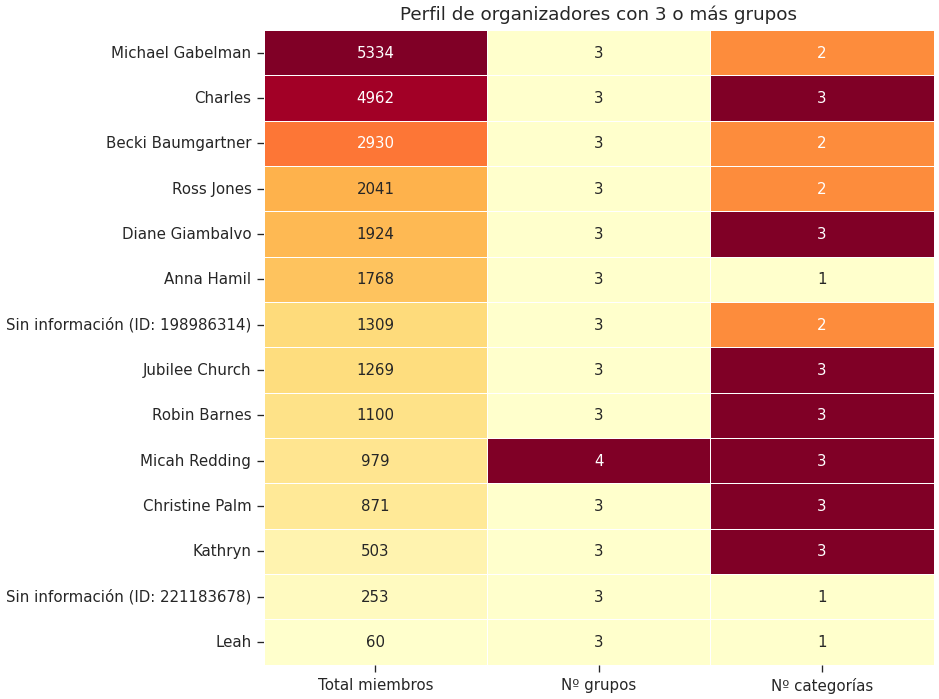

In [32]:
top_orgs = org_enriched[org_enriched['num_groups'] >= 3].copy()

mask = top_orgs['name'] == 'Sin información'
top_orgs['label'] = top_orgs['name']
top_orgs.loc[mask, 'label'] = [
    f"Sin información (ID: {idx})" for idx in top_orgs[mask].index
]

top_orgs_plot = top_orgs.set_index('label')[['total_members', 'num_groups', 'num_categories']]
top_orgs_plot.columns = ['Total miembros', 'Nº grupos', 'Nº categorías']
top_orgs_plot.index.name = ''

# Ordenar por total_members ascendente (seaborn invierte el eje Y)
top_orgs_plot = top_orgs_plot.sort_values('Total miembros', ascending=False)

top_orgs_norm = (top_orgs_plot - top_orgs_plot.min()) / (top_orgs_plot.max() - top_orgs_plot.min())

fig, ax = plt.subplots(figsize=FS["heatmap"])
sns.heatmap(
    top_orgs_norm, annot=top_orgs_plot, fmt='g',
    cmap=CMAP_HEAT, linewidths=0.4, ax=ax,
    cbar=False,
)
ax.set_title("Perfil de organizadores con 3 o más grupos")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
save_figure(fig, "02_organizers_heatmap.png")
plt.show()

### 4.6 Calidad de datos e integridad referencial

Se identificaron **29 organizadores (5.6%)** cuyos IDs no tienen correspondencia en `meta_members`, afectando a **35 grupos**. Entre los grupos afectados se encuentran algunos de los más relevantes del dataset, como PyNash (1.442 miembros) y Nashville Social Crew (4.017 miembros), lo que sugiere que estos grupos podrían estar gestionados por entidades o cuentas corporativas en lugar de miembros individuales. Este hallazgo constituye una limitación de integridad referencial del dataset que debe tenerse en cuenta en fases posteriores del análisis.

In [33]:
# ── Integridad referencial organizer_id ───────────────────────────────────
org_ids = set(meta_groups['organizer_id'].unique())
member_ids = set(meta_members['member_id'].unique())

org_not_in_members = org_ids - member_ids
org_in_members = org_ids & member_ids

print(f"Total organizadores únicos          : {len(org_ids)}")
print(f"Organizadores en meta_members       : {len(org_in_members)} ({len(org_in_members)/len(org_ids)*100:.1f}%)")
print(f"Organizadores NO en meta_members    : {len(org_not_in_members)} ({len(org_not_in_members)/len(org_ids)*100:.1f}%)")

# ¿Cuántos grupos afecta?
grupos_afectados = meta_groups[meta_groups['organizer_id'].isin(org_not_in_members)]
print(f"\nGrupos con organizador no registrado: {len(grupos_afectados)}")
print(grupos_afectados[['group_name', 'category_name', 'num_members', 'organizer_id']].to_string())

Total organizadores únicos          : 522
Organizadores en meta_members       : 493 (94.4%)
Organizadores NO en meta_members    : 29 (5.6%)

Grupos con organizador no registrado: 35
                                                       group_name            category_name  num_members  organizer_id
11                                                         PyNash                     Tech         1442     215201845
31                                       Nashville Product Meetup                     Tech          560      86371752
53                 Nashville Salesforce Admins & Developers Group                     Tech          501     204135137
54                                         Outdoor Afro-Nashville     Outdoors & Adventure          113      87574402
86                                Nashville Entrepreneurs Network        Career & Business         1192     201177047
87                                  Nashville Freelance Creatives           Arts & Culture          223      1

### 4.7 Relevancia para detección de anomalías

El análisis de `meta_groups` arroja varios candidatos a anomalía estructural. Los **68 grupos outlier por num_members** representan nodos de grado potencialmente muy alto en el grafo bipartito. Los **organizadores multi-categoría** como Micah Redding, Charles o Michael Gabelman serán previsiblemente nodos puente entre comunidades. Los **13 grupos con menos de 10 miembros** podrían corresponder a nodos aislados o periféricos en el grafo. Finalmente, los **patrones coordinados** como los grupos #Resist o los grupos de Jubilee Church representan estructuras de comunidad intencionalmente diseñadas, cuyo comportamiento en el grafo puede diferir significativamente del resto.

---

## 5. EDA — meta_events

### 5.1 Estadísticas básicas

El dataset contiene **19.307 eventos únicos** distribuidos entre los **602 grupos** ya identificados en `meta_groups`, lo que supone una media de 32 eventos por grupo. Sin embargo, la fuerte asimetría de la distribución (mediana de 12 eventos) indica que esta media está inflada por grupos muy activos, siendo lo más habitual grupos con menos de 25 eventos. El rango temporal abarca exactamente **729 días**, desde noviembre de 2015 hasta octubre de 2017, cubriendo dos años completos de actividad.

In [34]:
# ── meta_events ────────────────────────────────────────────────────────────

print(f"📊 Estadísticas básicas - meta_events")
print(f"  Total eventos    : {meta_events['event_id'].nunique()}")
print(f"  Total grupos     : {meta_events['group_id'].nunique()}")
print(f"\n📊 Estadísticas descriptivas:")
display(meta_events.describe(include='all'))

# Eventos por grupo
events_per_group = meta_events.groupby('group_id')['event_id'].count().sort_values(ascending=False)
print(f"\n📊 Estadísticas de eventos por grupo:")
print(events_per_group.describe())
print(f"\nTop 10 grupos por nº de eventos:")
print(events_per_group.head(10))
print(f"\nGrupos con un solo evento: {(events_per_group == 1).sum()}")

# Parsear fechas
meta_events['time'] = pd.to_datetime(meta_events['time'], format='mixed')
print(f"\n📅 Rango temporal:")
print(f"  Primer evento : {meta_events['time'].min()}")
print(f"  Último evento : {meta_events['time'].max()}")
print(f"  Rango total   : {(meta_events['time'].max() - meta_events['time'].min()).days} días")

📊 Estadísticas básicas - meta_events
  Total eventos    : 19307
  Total grupos     : 602

📊 Estadísticas descriptivas:


,event_id,group_id,name,time
count,19307,1.930700e+04,19307,19307
unique,19307,NaN,8869,8724
top,243930425,NaN,FREE Reiki Share & Chakra Balancing - Everyon...,2017-04-20 23:30:00
freq,1,NaN,116,26
mean,NaN,1.199424e+07,NaN,NaN
std,NaN,8.373233e+06,NaN,NaN
min,NaN,4.709400e+04,NaN,NaN
25%,NaN,1.751502e+06,NaN,NaN
50%,NaN,1.439681e+07,NaN,NaN
75%,NaN,1.904954e+07,NaN,NaN



📊 Estadísticas de eventos por grupo:
count    602.000000
mean      32.071429
std       50.496304
min        1.000000
25%        3.000000
50%       12.000000
75%       30.750000
max      200.000000
Name: event_id, dtype: float64

Top 10 grupos por nº de eventos:
group_id
47094       200
168014      200
1324203     200
18823274    200
18476981    200
1526075     200
18361585    200
18243826    200
1585196     200
17487002    200
Name: event_id, dtype: int64

Grupos con un solo evento: 81

📅 Rango temporal:
  Primer evento : 2015-11-01 01:00:00
  Último evento : 2017-10-30 23:15:00
  Rango total   : 729 días


### 5.2 Distribución de eventos por grupo y truncamiento de la API

La distribución de eventos por grupo presenta la misma **asimetría positiva** observada en `meta_groups` con `num_members`. La gran mayoría de grupos concentra pocos eventos, mientras una minoría acumula una actividad muy superior a la media.

Un hallazgo crítico es la presencia de **32 grupos (5.3%) con exactamente 200 eventos**, valor que corresponde al **límite de extracción de la API de Meetup** y no al número real de eventos celebrados. Estos grupos son precisamente los más activos y con mayor número de miembros del dataset — Nashville Hiking Meetup, Tennessee Hiking Group, Nashville Social Crew, entre otros — lo que significa que el truncamiento afecta de forma desproporcionada a los nodos más relevantes de la red. En total, **6.400 eventos (33.1% del dataset) provienen de grupos truncados**, lo cual constituye una limitación seria para cualquier análisis de actividad posterior.

En el extremo opuesto, **81 grupos tienen un único evento registrado**, correspondiendo probablemente a grupos recién creados o abandonados tras su primera actividad. La integridad referencial entre `meta_events` y `meta_groups` es perfecta: todos los `group_id` presentes en `meta_events` tienen correspondencia en `meta_groups`.

Grupos con exactamente 200 eventos: 32
Porcentaje del total: 5.3%

Grupos afectados:
                                           group_name           category_name  num_members
0                             Nashville Hiking Meetup    Outdoors & Adventure        15838
7                              Tennessee Hiking Group    Outdoors & Adventure         4828
8              ¡Diablos Que Bailan! (Salsa Nashville)                 Dancing         3472
112              Hiking Club of Nashville and Suburbs    Outdoors & Adventure         3381
12                       The Nashville Writers Meetup                 Writing         3286
2                                    Nashville soccer     Sports & Recreation         2869
14            Nashville Area Gamer Association - NAGA                   Games         2730
10                              Middle TN 40+ singles                 Singles         2583
64                                       Drink-n-Draw          Arts & Culture         2514
21   

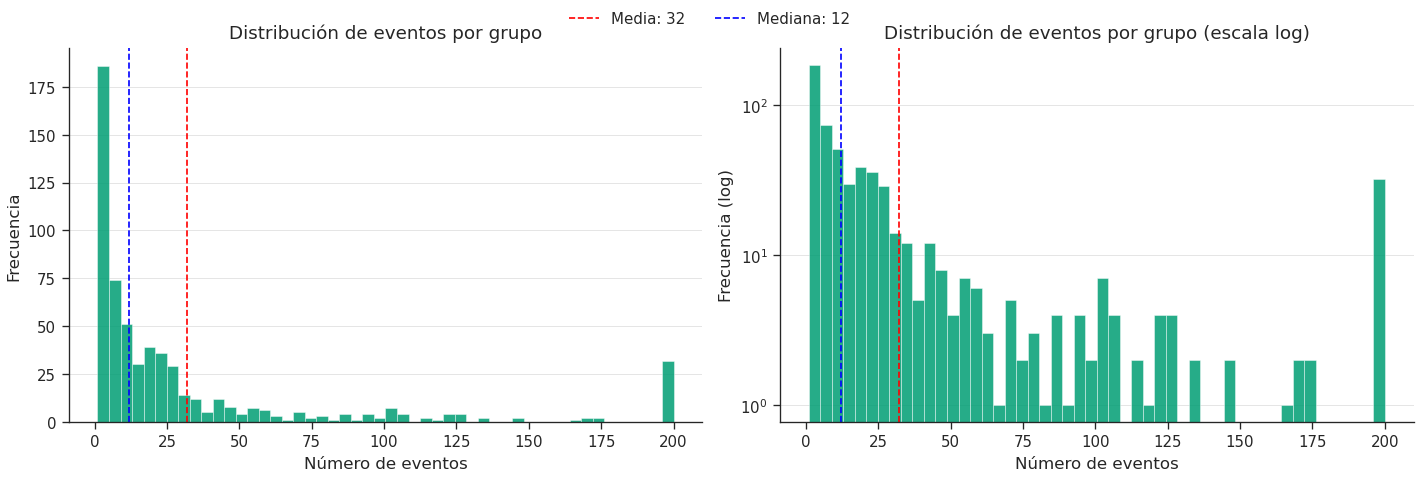

In [35]:
# Grupos con exactamente 200 eventos (posible límite de API)
grupos_200 = events_per_group[events_per_group == 200]
print(f"Grupos con exactamente 200 eventos: {len(grupos_200)}")
print(f"Porcentaje del total: {len(grupos_200)/len(events_per_group)*100:.1f}%")

# Enriquecer con meta_groups
grupos_200_info = meta_groups[meta_groups['group_id'].isin(grupos_200.index)][
    ['group_name', 'category_name', 'num_members']
].sort_values('num_members', ascending=False)
print(f"\nGrupos afectados:")
print(grupos_200_info.to_string())

# Distribución de eventos por grupo
fig, axes = plt.subplots(1, 2, figsize=FS["r1c2"])

mean_val   = events_per_group.mean()
median_val = events_per_group.median()

for ax in axes:
    ax.hist(events_per_group, bins=50, color=PALETTE["MG"],
            alpha=0.85, edgecolor="white", linewidth=0.3,
            log=(ax == axes[1]))
    ax.axvline(mean_val,   color="red",  linestyle="--", linewidth=1.0)
    ax.axvline(median_val, color="blue", linestyle="--", linewidth=1.0)

axes[0].set_title("Distribución de eventos por grupo")
axes[0].set_xlabel("Número de eventos")
axes[0].set_ylabel("Frecuencia")
polish(axes[0])

axes[1].set_title("Distribución de eventos por grupo (escala log)")
axes[1].set_xlabel("Número de eventos")
axes[1].set_ylabel("Frecuencia (log)")
axes[1].yaxis.set_major_locator(plt.LogLocator(base=10, numticks=10))
axes[1].yaxis.set_major_formatter(plt.LogFormatterMathtext(base=10, labelOnlyBase=True))
axes[1].yaxis.set_minor_locator(plt.NullLocator())
polish(axes[1])

handles = [
    plt.Line2D([0], [0], color="red",  linestyle="--", linewidth=1.0, label=f"Media: {mean_val:.0f}"),
    plt.Line2D([0], [0], color="blue", linestyle="--", linewidth=1.0, label=f"Mediana: {median_val:.0f}"),
]
fig.legend(handles=handles, loc="upper center", ncol=2,
           frameon=False, fontsize=FONT["legend"],
           bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
save_figure(fig, "02_events_per_group_distribution.png")
plt.show()

### 5.3 Análisis temporal

La serie temporal mensual muestra una **tendencia de crecimiento prácticamente monotónica** a lo largo de los dos años del dataset. El volumen de eventos pasa de los ~400 mensuales a finales de 2015 hasta superar los 1.400 en octubre de 2017, reflejando una comunidad en plena expansión durante el periodo de captura. Se aprecia una leve caída estacional en noviembre-diciembre de 2016, coherente con la reducción de actividad social típica del periodo navideño.

El **sábado es el día con mayor número de eventos** (más de 4.000), seguido del domingo, lo que indica que los meetups de Tennessee son mayoritariamente actividades de fin de semana. Entre semana, el patrón es relativamente uniforme de martes a jueves, con una caída notable el viernes y el mínimo absoluto el lunes.

In [36]:
# Marcar grupos truncados
grupos_truncados = set(grupos_200.index)
meta_events['truncated'] = meta_events['group_id'].isin(grupos_truncados)

print(f"Eventos de grupos truncados : {meta_events['truncated'].sum()} ({meta_events['truncated'].sum()/len(meta_events)*100:.1f}%)")
print(f"Eventos de grupos normales  : {(~meta_events['truncated']).sum()} ({(~meta_events['truncated']).sum()/len(meta_events)*100:.1f}%)")

# Integridad referencial: group_id en meta_events vs meta_groups
event_groups = set(meta_events['group_id'].unique())
meta_group_ids = set(meta_groups['group_id'].unique())

groups_not_in_meta = event_groups - meta_group_ids
print(f"\nGrupos en meta_events no encontrados en meta_groups: {len(groups_not_in_meta)}")

Eventos de grupos truncados : 6400 (33.1%)
Eventos de grupos normales  : 12907 (66.9%)

Grupos en meta_events no encontrados en meta_groups: 0


### 5.4 Calidad de datos: distribución horaria

La distribución por hora del día revela un **problema de calidad relevante**: los picos en las horas 0 y 23 son los más altos de todo el día, lo cual es inconsistente con el comportamiento esperado de eventos sociales. El análisis detallado confirma que **2.525 eventos (13.1%) tienen hora 00:00:00** — probablemente eventos registrados sin hora específica a los que la plataforma asigna medianoche por defecto — y **2.262 eventos (11.7%) tienen hora 23:00:00**, valor que también aparece como posible hora por defecto en Meetup. Un tercer grupo minoritario de 97 eventos (0.5%) presenta la hora 23:15:00 como posible valor de relleno.

En total, el **25.3% de los eventos tienen una hora de inicio no fiable**. Una vez excluidos estos valores, la distribución horaria real muestra el patrón esperable: actividad concentrada entre las 13h y las 20h, con el pico en torno a las 15-17h.

[viz] saved -> C:\Personal\MCD\TFM\results\figures\02_events_temporal_analysis.png


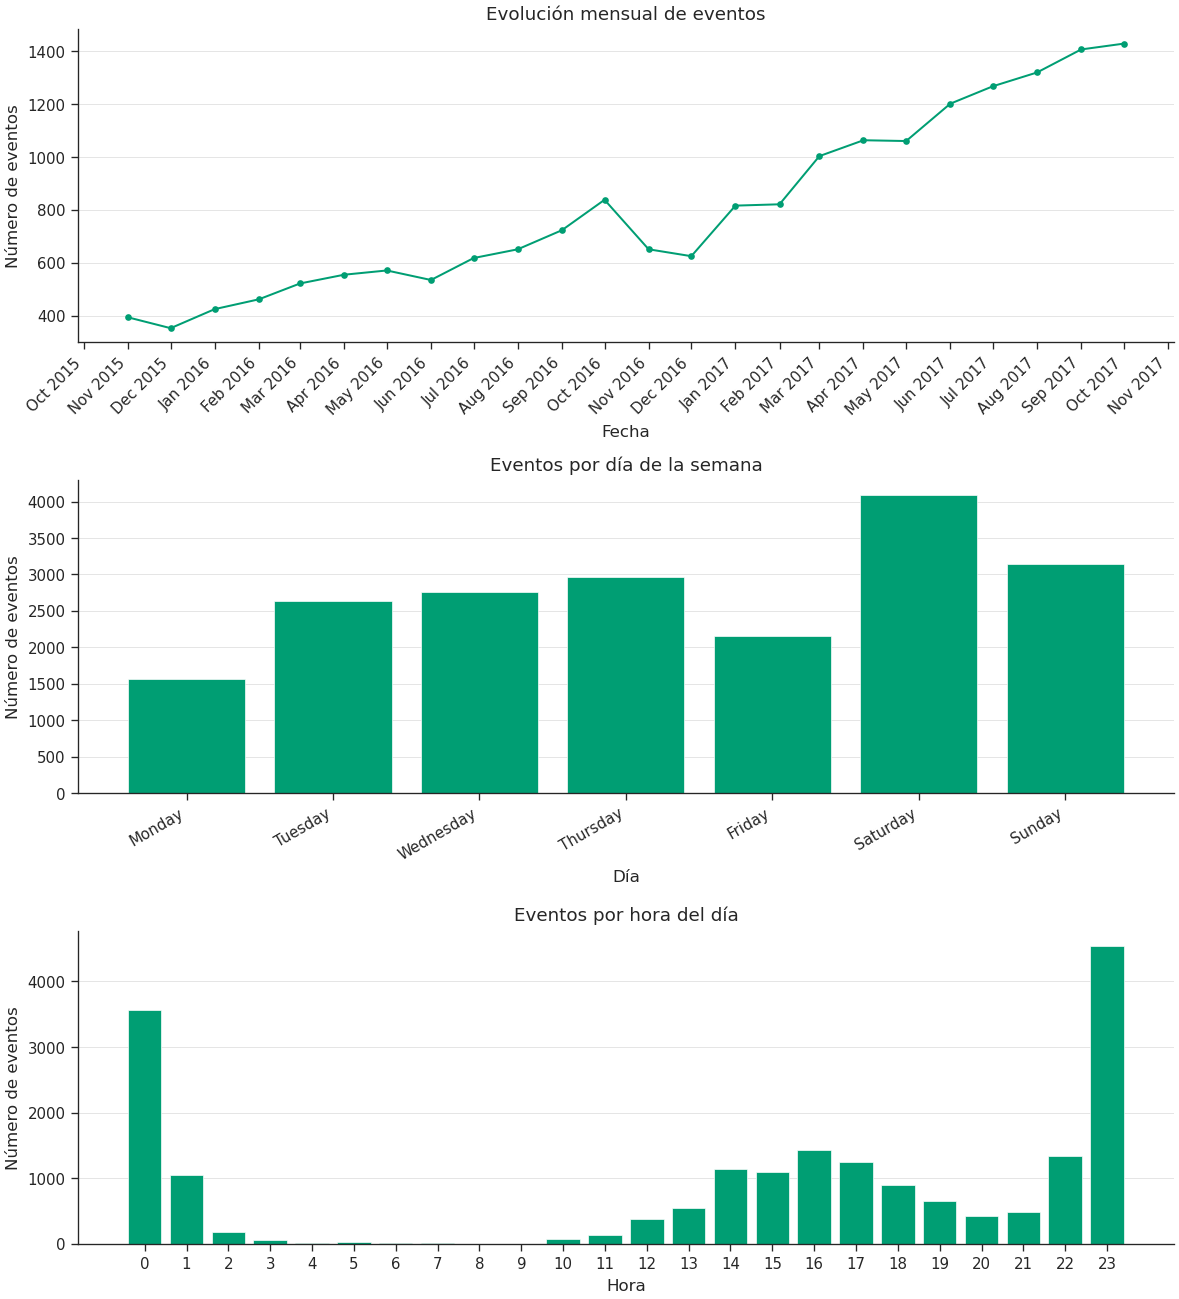

📅 Distribución por año:
year
2015      747
2016     7176
2017    11384
Name: count, dtype: int64

📅 Top 5 meses con más eventos:
         date  event_id
23 2017-10-01      1428
22 2017-09-01      1406
21 2017-08-01      1319
20 2017-07-01      1267
19 2017-06-01      1201

📅 Top 5 meses con menos eventos:
        date  event_id
1 2015-12-01       353
0 2015-11-01       394
2 2016-01-01       425
3 2016-02-01       462
4 2016-03-01       522


In [37]:
# ── Análisis temporal ─────────────────────────────────────────────────────

# Extraer componentes temporales
meta_events['year']  = meta_events['time'].dt.year
meta_events['month'] = meta_events['time'].dt.month
meta_events['dow']   = meta_events['time'].dt.day_name()
meta_events['hour']  = meta_events['time'].dt.hour

# Eventos por mes
events_by_month = meta_events.groupby(['year', 'month'])['event_id'].count().reset_index()
events_by_month['date'] = pd.to_datetime(events_by_month[['year', 'month']].assign(day=1))

# Eventos por día de la semana
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
events_by_dow = meta_events['dow'].value_counts().reindex(dow_order)

# Eventos por hora
events_by_hour = meta_events['hour'].value_counts().sort_index()

# Visualización — wider than FS["r3c1"] to fit monthly date labels
fig, axes = plt.subplots(3, 1, figsize=(10, 11))

# Serie temporal mensual
axes[0].plot(events_by_month['date'], events_by_month['event_id'],
             color=PALETTE["MG"], marker='o', markersize=3, linewidth=1.2)
axes[0].set_title("Evolución mensual de eventos")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Número de eventos")
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
polish(axes[0])

# Día de la semana
axes[1].bar(events_by_dow.index, events_by_dow.values, color=PALETTE["MG"])
axes[1].set_title("Eventos por día de la semana")
axes[1].set_xlabel("Día")
axes[1].set_ylabel("Número de eventos")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')
polish(axes[1])

# Hora del día
axes[2].bar(events_by_hour.index, events_by_hour.values, color=PALETTE["MG"])
axes[2].set_title("Eventos por hora del día")
axes[2].set_xlabel("Hora")
axes[2].set_ylabel("Número de eventos")
axes[2].set_xticks(range(0, 24))
polish(axes[2])

plt.tight_layout()
save_figure(fig, "02_events_temporal_analysis.png")
plt.show()

# Estadísticas temporales
print("📅 Distribución por año:")
print(meta_events['year'].value_counts().sort_index())
print("\n📅 Top 5 meses con más eventos:")
print(events_by_month.nlargest(5, 'event_id')[['date', 'event_id']].to_string())
print("\n📅 Top 5 meses con menos eventos:")
print(events_by_month.nsmallest(5, 'event_id')[['date', 'event_id']].to_string())

In [38]:
# Investigar horas sospechosas (23 y 0)
print("Eventos a las 00:00:00 exactas:")
midnight = meta_events[meta_events['time'].dt.time == pd.Timestamp('00:00:00').time()]
print(f"  Total: {len(midnight)} ({len(midnight)/len(meta_events)*100:.1f}%)")

print("\nEventos a las 23:00:00 exactas:")
h23 = meta_events[meta_events['time'].dt.time == pd.Timestamp('23:00:00').time()]
print(f"  Total: {len(h23)} ({len(h23)/len(meta_events)*100:.1f}%)")

print("\nEventos a las 23:15:00 exactas:")
h2315 = meta_events[meta_events['time'].dt.time == pd.Timestamp('23:15:00').time()]
print(f"  Total: {len(h2315)} ({len(h2315)/len(meta_events)*100:.1f}%)")

# Eventos sin hora (solo fecha, hora 00:00)
only_date = meta_events[meta_events['time'].dt.strftime('%H:%M:%S') == '00:00:00']
print(f"\nEventos con hora 00:00:00 (posible fecha sin hora): {len(only_date)} ({len(only_date)/len(meta_events)*100:.1f}%)")

# Muestra de eventos a las 23:xx
print("\nMuestra de eventos a las 23h:")
print(meta_events[meta_events['hour'] == 23][['event_id', 'group_id', 'name', 'time']].sample(10).to_string())

Eventos a las 00:00:00 exactas:
  Total: 2525 (13.1%)

Eventos a las 23:00:00 exactas:
  Total: 2262 (11.7%)

Eventos a las 23:15:00 exactas:
  Total: 97 (0.5%)

Eventos con hora 00:00:00 (posible fecha sin hora): 2525 (13.1%)

Muestra de eventos a las 23h:
           event_id  group_id                                                                              name                time
5595   fcvnwlyvnbxb   7151442                                                 Automated Testing with Test Cloud 2016-10-18 23:00:00
15201  qdjhpmywmbbc  22197221                                     Nutritious & Delicious Cooking Demo: Deserts! 2017-09-20 23:00:00
5117      239148300  18849449                                            Monthly women of Courage and strength  2017-04-12 23:30:00
4273   rwmksnywmblc  24850344                    Show up, meet folks, cuss and discuss and eat a little dinner. 2017-09-28 23:00:00
18640  bjhwwlywmbcc   1585196                      Night hikes on Mossy Ridge (Red

### 5.5 Relevancia para detección de anomalías

El análisis de `meta_events` aporta dos dimensiones relevantes para la detección de anomalías. Por un lado, los **32 grupos truncados** representan nodos cuya actividad real es desconocida y superior a la registrada, lo que puede distorsionar métricas de centralidad y actividad en el grafo. Por otro lado, los **patrones temporales anómalos** — horas por defecto, grupos con un único evento — constituyen señales de baja calidad de datos que conviene filtrar o tratar antes de construir las features para los modelos de detección.